<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_spectral_resonance_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

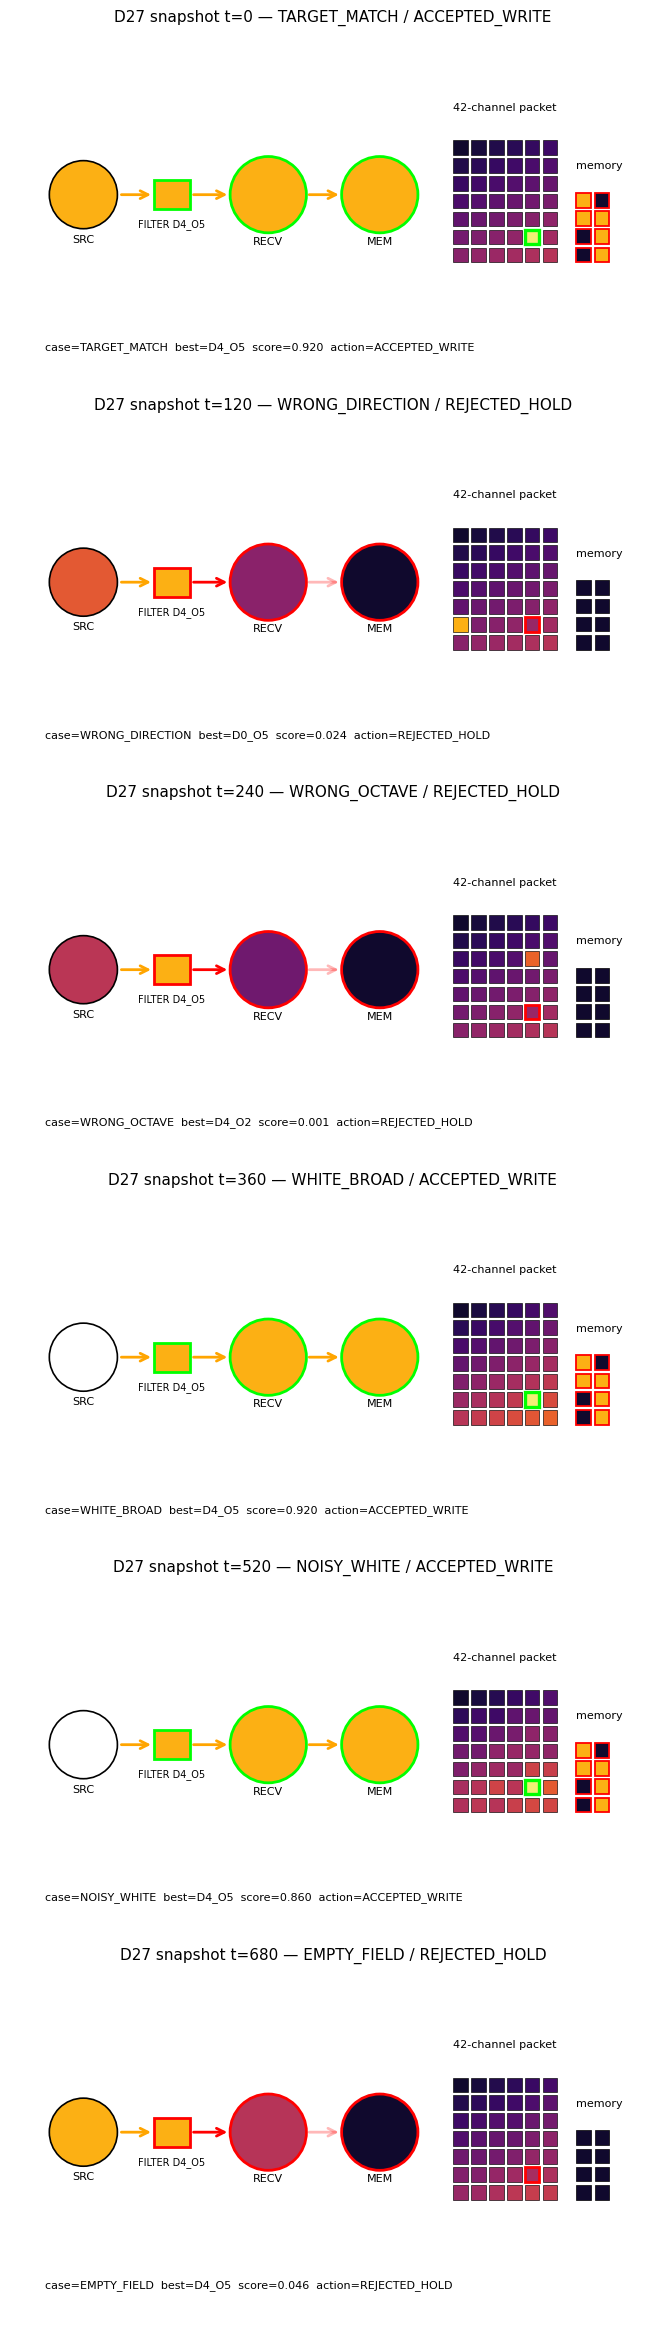

STATE: SPECTRAL_RESONANCE_LOCKED
input sequence:        10110101
target key:            D4_O5
target state id:       34
spectral states:       42
directions x octaves:  6 x 7
cases tested:          6
accepted cases:        3
rejected cases:        3
filter precision:      1.0
threshold:             0.62

Case decision table:


,STATE,CASE,RESULT,TARGET_KEY,BEST_KEY,BEST_STATE_ID,BEST_SCORE,ACCEPTED,WRITTEN_SEQUENCE,READOUT_SEQUENCE,WRITE_ACCURACY,ISOLATION_OK
0,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,SPECTRAL_ACCEPTED,D4_O5,D4_O5,34,0.920,1,10110101,10110101,1.0,1
1,D27_SPECTRAL_RESONANCE_FILTER,WRONG_DIRECTION,SPECTRAL_REJECTED,D4_O5,D0_O5,30,0.024,0,00000000,00000000,0.0,1
2,D27_SPECTRAL_RESONANCE_FILTER,WRONG_OCTAVE,SPECTRAL_REJECTED,D4_O5,D4_O2,16,0.001,0,00000000,00000000,0.0,1
3,D27_SPECTRAL_RESONANCE_FILTER,WHITE_BROAD,SPECTRAL_ACCEPTED,D4_O5,D4_O5,34,0.920,1,10110101,10110101,1.0,1
4,D27_SPECTRAL_RESONANCE_FILTER,NOISY_WHITE,SPECTRAL_ACCEPTED,D4_O5,D4_O5,34,0.860,1,10110101,10110101,1.0,1
5,D27_SPECTRAL_RESONANCE_FILTER,EMPTY_FIELD,SPECTRAL_REJECTED,D4_O5,D4_O4,28,0.033,0,00000000,00000000,0.0,1



Target-channel score table:


,STATE,CASE,DIRECTION,OCTAVE,SPECTRAL_KEY,STATE_ID,AMPLITUDE,RESONANCE_SCORE,IS_TARGET
0,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,4,5,D4_O5,34,0.920,0.920,1
1,D27_SPECTRAL_RESONANCE_FILTER,WRONG_DIRECTION,4,5,D4_O5,34,0.000,0.000,1
2,D27_SPECTRAL_RESONANCE_FILTER,WRONG_OCTAVE,4,5,D4_O5,34,0.000,0.000,1
3,D27_SPECTRAL_RESONANCE_FILTER,WHITE_BROAD,4,5,D4_O5,34,0.920,0.920,1
4,D27_SPECTRAL_RESONANCE_FILTER,NOISY_WHITE,4,5,D4_O5,34,0.860,0.860,1
5,D27_SPECTRAL_RESONANCE_FILTER,EMPTY_FIELD,4,5,D4_O5,34,0.001,0.001,1



Memory write table:


,STATE,CASE,MEMORY_SLOT,INPUT_BIT,MEMORY_BEFORE,MEMORY_AFTER,WRITTEN,MATCH_IF_ACCEPTED
0,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,0,1,0,1,1,1
1,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,1,0,0,0,1,1
2,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,2,1,0,1,1,1
3,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,3,1,0,1,1,1
4,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,4,0,0,0,1,1
5,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,5,1,0,1,1,1
6,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,6,0,0,0,1,1
7,D27_SPECTRAL_RESONANCE_FILTER,TARGET_MATCH,7,1,0,1,1,1
8,D27_SPECTRAL_RESONANCE_FILTER,WRONG_DIRECTION,0,1,0,0,0,not_written
9,D27_SPECTRAL_RESONANCE_FILTER,WRONG_DIRECTION,1,0,0,0,0,not_written



Summary:


,STATE,RESULT,INPUT_SEQUENCE,TARGET_KEY,TARGET_STATE_ID,SPECTRAL_STATES,DIRECTIONS,OCTAVES,CASES_TESTED,ACCEPTED_CASES,REJECTED_CASES,FILTER_PRECISION,RESONANCE_THRESHOLD
0,D27_SPECTRAL_RESONANCE_FILTER,SPECTRAL_RESONANCE_LOCKED,10110101,D4_O5,34,42,6,7,6,3,3,1.0,0.62


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D27_SPECTRAL_RESONANCE_FILTER
# Field memory spectral resonance gate
#
# Goal:
# white / broad field signal
# -> 42 spectral channels: 6 directions x 7 octaves
# -> receiver has one resonance key
# -> only matching spectral channel is accepted
# -> accepted signal writes memory
# -> wrong color / wrong octave / noise are rejected
# ============================================================

np.random.seed(27)

STATE = "D27_SPECTRAL_RESONANCE_FILTER"

input_sequence = "10110101"

directions = 6
octaves = 7
total_states = directions * octaves

target_direction = 4
target_octave = 5
target_state_id = target_octave * directions + target_direction
target_key = f"D{target_direction}_O{target_octave}"

resonance_threshold = 0.62
decode_threshold = 0.50

memory_before = "00000000"


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def seq_to_bits(seq):
    return [int(x) for x in seq]


def state_key(direction, octave):
    return f"D{direction}_O{octave}"


def state_id(direction, octave):
    return octave * directions + direction


def circular_distance(a, b, mod):
    d = abs(a - b)
    return min(d, mod - d)


def spectral_color(direction, octave, strength=1.0):
    base = (octave / max(1, octaves - 1)) * 0.65 + (direction / max(1, directions - 1)) * 0.25
    value = np.clip(0.08 + base * strength, 0.05, 0.95)
    return plt.cm.inferno(value)


def channel_score(direction, octave, amplitude):
    d_dist = circular_distance(direction, target_direction, directions)
    o_dist = abs(octave - target_octave)

    direction_match = np.exp(-(d_dist ** 2) / 1.1)
    octave_match = np.exp(-(o_dist ** 2) / 1.3)

    return float(amplitude * direction_match * octave_match)


def make_packet(case_name):
    amplitudes = np.zeros((octaves, directions), dtype=float)

    if case_name == "TARGET_MATCH":
        amplitudes[target_octave, target_direction] = 0.92

    elif case_name == "WRONG_DIRECTION":
        amplitudes[target_octave, (target_direction + 2) % directions] = 0.92

    elif case_name == "WRONG_OCTAVE":
        wrong_octave = max(0, target_octave - 3)
        amplitudes[wrong_octave, target_direction] = 0.92

    elif case_name == "WHITE_BROAD":
        amplitudes[:, :] = 0.18
        amplitudes[target_octave, target_direction] = 0.92

    elif case_name == "NOISY_WHITE":
        amplitudes[:, :] = np.random.uniform(0.08, 0.30, size=(octaves, directions))
        amplitudes[target_octave, target_direction] = 0.86

    elif case_name == "EMPTY_FIELD":
        amplitudes[:, :] = np.random.uniform(0.00, 0.08, size=(octaves, directions))

    return amplitudes


cases = [
    "TARGET_MATCH",
    "WRONG_DIRECTION",
    "WRONG_OCTAVE",
    "WHITE_BROAD",
    "NOISY_WHITE",
    "EMPTY_FIELD",
]


case_rows = []
channel_rows = []
memory_rows = []

memory_after_by_case = {}

for case in cases:
    packet = make_packet(case)

    scores = np.zeros_like(packet)

    for octave in range(octaves):
        for direction in range(directions):
            amp = float(packet[octave, direction])
            score = channel_score(direction, octave, amp)
            scores[octave, direction] = score

            channel_rows.append({
                "STATE": STATE,
                "CASE": case,
                "DIRECTION": direction,
                "OCTAVE": octave,
                "SPECTRAL_KEY": state_key(direction, octave),
                "STATE_ID": state_id(direction, octave),
                "AMPLITUDE": round(amp, 3),
                "RESONANCE_SCORE": round(score, 3),
                "IS_TARGET": int(direction == target_direction and octave == target_octave)
            })

    best_index = np.unravel_index(np.argmax(scores), scores.shape)
    best_octave = int(best_index[0])
    best_direction = int(best_index[1])
    best_score = float(scores[best_octave, best_direction])

    accepted = (
        best_score >= resonance_threshold
        and best_direction == target_direction
        and best_octave == target_octave
    )

    result = "SPECTRAL_ACCEPTED" if accepted else "SPECTRAL_REJECTED"

    written_sequence = input_sequence if accepted else memory_before
    readout_sequence = written_sequence

    write_accuracy = float(np.mean(np.array(seq_to_bits(written_sequence)) == np.array(seq_to_bits(input_sequence)))) if accepted else 0.0
    isolation_ok = int(not accepted or written_sequence == input_sequence)

    case_rows.append({
        "STATE": STATE,
        "CASE": case,
        "RESULT": result,
        "TARGET_KEY": target_key,
        "BEST_KEY": state_key(best_direction, best_octave),
        "BEST_STATE_ID": state_id(best_direction, best_octave),
        "BEST_SCORE": round(best_score, 3),
        "ACCEPTED": int(accepted),
        "WRITTEN_SEQUENCE": written_sequence,
        "READOUT_SEQUENCE": readout_sequence,
        "WRITE_ACCURACY": round(write_accuracy, 3),
        "ISOLATION_OK": isolation_ok
    })

    memory_after_by_case[case] = written_sequence

    for i, bit in enumerate(input_sequence):
        memory_rows.append({
            "STATE": STATE,
            "CASE": case,
            "MEMORY_SLOT": i,
            "INPUT_BIT": int(bit),
            "MEMORY_BEFORE": int(memory_before[i]),
            "MEMORY_AFTER": int(written_sequence[i]),
            "WRITTEN": int(accepted),
            "MATCH_IF_ACCEPTED": int(written_sequence[i] == bit) if accepted else "not_written"
        })


df_cases = pd.DataFrame(case_rows)
df_channels = pd.DataFrame(channel_rows)
df_memory = pd.DataFrame(memory_rows)

accepted_cases = int(df_cases["ACCEPTED"].sum())
rejected_cases = len(df_cases) - accepted_cases

target_cases_ok = int(df_cases[df_cases["CASE"].isin(["TARGET_MATCH", "WHITE_BROAD", "NOISY_WHITE"])]["ACCEPTED"].sum() == 3)
reject_cases_ok = int(df_cases[df_cases["CASE"].isin(["WRONG_DIRECTION", "WRONG_OCTAVE", "EMPTY_FIELD"])]["ACCEPTED"].sum() == 0)

filter_precision = 1.0 if target_cases_ok and reject_cases_ok else 0.0

result = "SPECTRAL_RESONANCE_LOCKED" if filter_precision == 1.0 else "SPECTRAL_RESONANCE_PARTIAL"

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "INPUT_SEQUENCE": input_sequence,
    "TARGET_KEY": target_key,
    "TARGET_STATE_ID": target_state_id,
    "SPECTRAL_STATES": total_states,
    "DIRECTIONS": directions,
    "OCTAVES": octaves,
    "CASES_TESTED": len(cases),
    "ACCEPTED_CASES": accepted_cases,
    "REJECTED_CASES": rejected_cases,
    "FILTER_PRECISION": filter_precision,
    "RESONANCE_THRESHOLD": resonance_threshold
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def draw_arrow(ax, start, end, active=True, reject=False):
    color = "red" if reject else "orange" if active else "gray"
    alpha = 1.0 if active else 0.28

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=2.0,
        color=color,
        alpha=alpha
    )
    ax.add_patch(arrow)


def draw_spectral_grid(ax, x0, y0, packet, scores, title):
    cell = 0.25
    gap = 0.055

    ax.text(x0, y0 + 2.55, title, fontsize=8, color="black", ha="left", va="bottom")

    for octave in range(octaves):
        for direction in range(directions):
            x = x0 + direction * (cell + gap)
            y = y0 + (octaves - 1 - octave) * (cell + gap)

            amp = packet[octave, direction]
            score = scores[octave, direction]

            face = spectral_color(direction, octave, 0.45 + amp)
            is_target = direction == target_direction and octave == target_octave
            locked = score >= resonance_threshold and is_target

            edge = "red" if is_target else "black"
            lw = 2.0 if is_target else 0.45

            if locked:
                edge = "lime"
                lw = 2.4

            rect = Rectangle(
                (x, y),
                cell,
                cell,
                facecolor=face,
                edgecolor=edge,
                linewidth=lw
            )
            ax.add_patch(rect)


def draw_memory_grid(ax, x0, y0, seq, title, selected=False):
    bits = seq_to_bits(seq)
    cell = 0.25
    gap = 0.06

    ax.text(x0, y0 + 1.55, title, fontsize=8, color="black", ha="left", va="bottom")

    for i, bit in enumerate(bits):
        col = i % 2
        row = i // 2

        x = x0 + col * (cell + gap)
        y = y0 + (3 - row) * (cell + gap)

        color = spectral_color(target_direction, target_octave, 1.0) if bit == 1 else spectral_color(0, 0, 0.45)

        edge = "red" if selected else "black"
        lw = 1.3 if selected else 0.5

        ax.add_patch(Rectangle(
            (x, y),
            cell,
            cell,
            facecolor=color,
            edgecolor=edge,
            linewidth=lw
        ))


def draw_snapshot(ax, case, t, phase):
    packet = make_packet(case)

    scores = np.zeros_like(packet)
    for octave in range(octaves):
        for direction in range(directions):
            scores[octave, direction] = channel_score(direction, octave, packet[octave, direction])

    best_index = np.unravel_index(np.argmax(scores), scores.shape)
    best_octave = int(best_index[0])
    best_direction = int(best_index[1])
    best_score = float(scores[best_octave, best_direction])

    accepted = (
        best_score >= resonance_threshold
        and best_direction == target_direction
        and best_octave == target_octave
    )

    ax.set_facecolor("white")
    ax.set_xlim(0, 11)
    ax.set_ylim(1.2, 7.2)
    ax.set_aspect("equal")
    ax.axis("off")

    wave = 0.5 + 0.5 * np.sin(2 * np.pi * phase)

    source_color = "white" if case in ["WHITE_BROAD", "NOISY_WHITE"] else spectral_color(best_direction, best_octave, 1.0)

    ax.add_patch(Circle((1.25, 4.4), 0.58, facecolor=source_color, edgecolor="black", linewidth=1.2))
    ax.text(1.25, 3.58, "SRC", fontsize=8, ha="center", color="black")

    filter_color = spectral_color(target_direction, target_octave, 1.0)
    filter_edge = "lime" if accepted else "red"

    ax.add_patch(Rectangle((2.45, 4.15), 0.62, 0.5, facecolor=filter_color, edgecolor=filter_edge, linewidth=2.0))
    ax.text(2.76, 3.84, f"FILTER {target_key}", fontsize=7, ha="center", color="black")

    receiver_color = filter_color if accepted else spectral_color(best_direction, best_octave, 0.55)
    receiver_edge = "lime" if accepted else "red"

    ax.add_patch(Circle((4.4, 4.4), 0.65, facecolor=receiver_color, edgecolor=receiver_edge, linewidth=2.0))
    ax.text(4.4, 3.55, "RECV", fontsize=8, ha="center", color="black")

    memory_seq = input_sequence if accepted else memory_before

    ax.add_patch(Circle((6.3, 4.4), 0.65, facecolor=receiver_color if accepted else spectral_color(0, 0, 0.4), edgecolor=receiver_edge, linewidth=2.0))
    ax.text(6.3, 3.55, "MEM", fontsize=8, ha="center", color="black")

    draw_arrow(ax, (1.85, 4.4), (2.45, 4.4), active=True, reject=False)
    draw_arrow(ax, (3.08, 4.4), (3.75, 4.4), active=True, reject=not accepted)
    draw_arrow(ax, (5.05, 4.4), (5.65, 4.4), active=accepted, reject=not accepted)

    draw_spectral_grid(ax, 7.55, 3.25, packet, scores, "42-channel packet")
    draw_memory_grid(ax, 9.65, 3.25, memory_seq, "memory", selected=accepted)

    status = "ACCEPTED_WRITE" if accepted else "REJECTED_HOLD"

    ax.text(
        0.6,
        1.75,
        f"case={case}  best={state_key(best_direction, best_octave)}  score={best_score:.3f}  action={status}",
        fontsize=8,
        ha="left",
        color="black"
    )

    ax.set_title(f"D27 snapshot t={t} — {case} / {status}", fontsize=11, color="black")


snapshots = [
    ("TARGET_MATCH", 0, 0.00),
    ("WRONG_DIRECTION", 120, 0.16),
    ("WRONG_OCTAVE", 240, 0.32),
    ("WHITE_BROAD", 360, 0.48),
    ("NOISY_WHITE", 520, 0.66),
    ("EMPTY_FIELD", 680, 0.82),
]

fig, axes = plt.subplots(len(snapshots), 1, figsize=(7.5, 3.9 * len(snapshots)))

for ax, (case, t, phase) in zip(axes, snapshots):
    draw_snapshot(ax, case, t, phase)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"input sequence:        {input_sequence}")
print(f"target key:            {target_key}")
print(f"target state id:       {target_state_id}")
print(f"spectral states:       {total_states}")
print(f"directions x octaves:  {directions} x {octaves}")
print(f"cases tested:          {len(cases)}")
print(f"accepted cases:        {accepted_cases}")
print(f"rejected cases:        {rejected_cases}")
print(f"filter precision:      {filter_precision}")
print(f"threshold:             {resonance_threshold}")

print("\nCase decision table:")
display(df_cases)

print("\nTarget-channel score table:")
display(
    df_channels[
        (df_channels["SPECTRAL_KEY"] == target_key)
    ].reset_index(drop=True)
)

print("\nMemory write table:")
display(df_memory)

print("\nSummary:")
display(df_summary)